In [26]:
# dependencies

from Bio import AlignIO
from Bio import SeqIO
import re
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
import scipy
from matplotlib.colors import LogNorm

In [2]:
# Converting BioCatNet fasta file to dataframe that includes the sequence and the family name

def biocatnet_fasta_to_df(input_fasta):
    data = {'accession': [], 'SFID': [], 'GI': [], 'taxonID': [], 'sequence': []}
    with open(input_fasta) as fp:
        for record in SeqIO.parse(fp, 'fasta'):
            accession = record.id
            sfid = re.findall(r"sfid\|(\d+)", record.id)
            gi = re.findall(r"gi\|(\d+)", record.id)
            taxonID = re.findall(r"taxonID\|(\d+)", record.id)
            sequence = str(record.seq)

            #Attach to dict.
            data['accession'].append(accession)
            data['SFID'].append(", ".join(sfid))
            data['GI'].append(", ".join(gi))
            data['taxonID'].append(", ".join(taxonID))
            data['sequence'].append(sequence)
    df = pd.DataFrame(data)
    return df

In [4]:
biocatnet_r1 = biocatnet_fasta_to_df('/home/alecia/chapter3-repo/output/hmm_search_1/biocatnet/3/ihelixhits_e_0p001_z__T_.fasta')
biocatnet_r2 = biocatnet_fasta_to_df('/home/alecia/chapter3-repo/output/hmm_search_1/biocatnet/3/ihelixhits_e_0p001_z__T_.fasta')

In [5]:
biocatnet_r1

,accession,SFID,GI,taxonID,sequence
0,sid|107075|pid|82008|hfid|211|sfid|6|gb|ERL945...,6,546684943,77166,-EDIMAQCF-VFFFAGFETSST--TMTFALLELAQH
1,sid|107075|pid|82008|hfid|211|sfid|6|gb|ERL945...,6,546684943,77166,-SDIIAQCF-VFFIAGFETSSS--TMTFTMLELAQH
2,sid|107075|pid|82008|hfid|211|sfid|6|gb|ERL945...,6,546684943,77166,-SDIIAQCF-VFFIAGFETSSS--TMTFTMLELAQH
3,sid|107075|pid|82008|hfid|211|sfid|6|gb|ERL945...,6,546684943,77166,-NDIIGQCF-VFFIAGFETSSS--TMTFTMLELAQN
4,sid|85794|pid|63405|hfid|120|sfid|4|gi|3544699...,4,"354469982, 537224038",10029,DKDLRAEVD-TFMFEGHDTTAS--GISWIFYALATH
...,...,...,...,...,...
29032,sid|23655|pid|18144|hfid|732|sfid|98|emb|CAE47...,98,40641242,4565,DDTVIGLLW-DMITAGTDTTVI--TVEWAVAELVRN
29033,sid|23713|pid|18186|hfid|732|sfid|98|emb|CDM84...,98,669030166,4565,DDTVIGLLW-DMITAGTDTTVI--TVEWAVAELVRN
29034,sid|3756|pid|2450|hfid|1051|sfid|142|gi|493288...,142,493288775,75922,DHQIVTEVL-LLLIGGDETTRH--TLSGGTRQLLRH
29035,sid|106334|pid|81326|hfid|210|sfid|6|gb|AGJ519...,6,478734979,1169899,-NELAAQAF-VFFIAGFETSST--TMTFCLFELASN


In [6]:
biocatnet_r2

,accession,SFID,GI,taxonID,sequence
0,sid|107075|pid|82008|hfid|211|sfid|6|gb|ERL945...,6,546684943,77166,-EDIMAQCF-VFFFAGFETSST--TMTFALLELAQH
1,sid|107075|pid|82008|hfid|211|sfid|6|gb|ERL945...,6,546684943,77166,-SDIIAQCF-VFFIAGFETSSS--TMTFTMLELAQH
2,sid|107075|pid|82008|hfid|211|sfid|6|gb|ERL945...,6,546684943,77166,-SDIIAQCF-VFFIAGFETSSS--TMTFTMLELAQH
3,sid|107075|pid|82008|hfid|211|sfid|6|gb|ERL945...,6,546684943,77166,-NDIIGQCF-VFFIAGFETSSS--TMTFTMLELAQN
4,sid|85794|pid|63405|hfid|120|sfid|4|gi|3544699...,4,"354469982, 537224038",10029,DKDLRAEVD-TFMFEGHDTTAS--GISWIFYALATH
...,...,...,...,...,...
29032,sid|23655|pid|18144|hfid|732|sfid|98|emb|CAE47...,98,40641242,4565,DDTVIGLLW-DMITAGTDTTVI--TVEWAVAELVRN
29033,sid|23713|pid|18186|hfid|732|sfid|98|emb|CDM84...,98,669030166,4565,DDTVIGLLW-DMITAGTDTTVI--TVEWAVAELVRN
29034,sid|3756|pid|2450|hfid|1051|sfid|142|gi|493288...,142,493288775,75922,DHQIVTEVL-LLLIGGDETTRH--TLSGGTRQLLRH
29035,sid|106334|pid|81326|hfid|210|sfid|6|gb|AGJ519...,6,478734979,1169899,-NELAAQAF-VFFIAGFETSST--TMTFCLFELASN


In [7]:
r1r2_merged_biocatnet = (pd.merge(biocatnet_r1, biocatnet_r2, how='outer', on=['GI', 'taxonID'])
                    .fillna(0))
r1r2_merged_biocatnet

,accession_x,SFID_x,GI,taxonID,sequence_x,accession_y,SFID_y,sequence_y
0,sid|110304|pid|33711|hfid|829|sfid|107/229-258,107,,,-QELLDHCI-GLLIAGHETTAS--QIPSFVYALL--,sid|110304|pid|33711|hfid|829|sfid|107/229-258,107,-QELLDHCI-GLLIAGHETTAS--QIPSFVYALL--
1,sid|19606|pid|14738|hfid|587|sfid|73|gb|ABF690...,73,100172835,3693,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,sid|19606|pid|14738|hfid|587|sfid|73|gb|ABF690...,73,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH
2,sid|19604|pid|14738|hfid|587|sfid|73|gb|ABF691...,73,100172857,3693,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,sid|19604|pid|14738|hfid|587|sfid|73|gb|ABF691...,73,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH
3,sid|19699|pid|14809|hfid|587|sfid|73|gb|ABF691...,73,100172876,3693,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,sid|19699|pid|14809|hfid|587|sfid|73|gb|ABF691...,73,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH
4,sid|19701|pid|14809|hfid|587|sfid|73|gb|ABF691...,73,100172892,3693,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,sid|19701|pid|14809|hfid|587|sfid|73|gb|ABF691...,73,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH
...,...,...,...,...,...,...,...,...
29146,sid|19552|pid|14713|hfid|587|sfid|73|gb|AAG092...,73,9957081,3888,DDNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,sid|19552|pid|14713|hfid|587|sfid|73|gb|AAG092...,73,DDNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH
29147,sid|19555|pid|14713|hfid|587|sfid|73|gb|AAG092...,73,9957085,3888,DDNVLYIVE-NINVAAMETTLW--SIEWGIAELVNH,sid|19555|pid|14713|hfid|587|sfid|73|gb|AAG092...,73,DDNVLYIVE-NINVAAMETTLW--SIEWGIAELVNH
29148,sid|58223|pid|41225|hfid|653|sfid|82|gb|AAG092...,82,9957087,3888,---IKATTL-ELILGGSDTTAG--TLTWAMCLLLKH,sid|58223|pid|41225|hfid|653|sfid|82|gb|AAG092...,82,---IKATTL-ELILGGSDTTAG--TLTWAMCLLLKH
29149,sid|19779|pid|14865|hfid|587|sfid|73|gb|AAG101...,73,9965897,29729,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,sid|19779|pid|14865|hfid|587|sfid|73|gb|AAG101...,73,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH


In [15]:
column = r1r2_merged_biocatnet['sequence_y']
r1r2_merged_biocatnet['char_y'] = column.str[17]
r1r2_merged_biocatnet['char_y2'] = column.str[18]

r1r2_merged_biocatnet

,accession_x,SFID_x,GI,taxonID,sequence_x,accession_y,SFID_y,sequence_y,char_x,char_x2,char_y,char_y2
0,sid|110304|pid|33711|hfid|829|sfid|107/229-258,107,,,-QELLDHCI-GLLIAGHETTAS--QIPSFVYALL--,sid|110304|pid|33711|hfid|829|sfid|107/229-258,107,-QELLDHCI-GLLIAGHETTAS--QIPSFVYALL--,E,T,E,T
1,sid|19606|pid|14738|hfid|587|sfid|73|gb|ABF690...,73,100172835,3693,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,sid|19606|pid|14738|hfid|587|sfid|73|gb|ABF690...,73,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,E,T,E,T
2,sid|19604|pid|14738|hfid|587|sfid|73|gb|ABF691...,73,100172857,3693,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,sid|19604|pid|14738|hfid|587|sfid|73|gb|ABF691...,73,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,E,T,E,T
3,sid|19699|pid|14809|hfid|587|sfid|73|gb|ABF691...,73,100172876,3693,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,sid|19699|pid|14809|hfid|587|sfid|73|gb|ABF691...,73,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,E,T,E,T
4,sid|19701|pid|14809|hfid|587|sfid|73|gb|ABF691...,73,100172892,3693,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,sid|19701|pid|14809|hfid|587|sfid|73|gb|ABF691...,73,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,E,T,E,T
...,...,...,...,...,...,...,...,...,...,...,...,...
29146,sid|19552|pid|14713|hfid|587|sfid|73|gb|AAG092...,73,9957081,3888,DDNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,sid|19552|pid|14713|hfid|587|sfid|73|gb|AAG092...,73,DDNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,E,T,E,T
29147,sid|19555|pid|14713|hfid|587|sfid|73|gb|AAG092...,73,9957085,3888,DDNVLYIVE-NINVAAMETTLW--SIEWGIAELVNH,sid|19555|pid|14713|hfid|587|sfid|73|gb|AAG092...,73,DDNVLYIVE-NINVAAMETTLW--SIEWGIAELVNH,E,T,E,T
29148,sid|58223|pid|41225|hfid|653|sfid|82|gb|AAG092...,82,9957087,3888,---IKATTL-ELILGGSDTTAG--TLTWAMCLLLKH,sid|58223|pid|41225|hfid|653|sfid|82|gb|AAG092...,82,---IKATTL-ELILGGSDTTAG--TLTWAMCLLLKH,D,T,D,T
29149,sid|19779|pid|14865|hfid|587|sfid|73|gb|AAG101...,73,9965897,29729,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,sid|19779|pid|14865|hfid|587|sfid|73|gb|AAG101...,73,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,E,T,E,T


In [16]:
# If sequence in I_Helix y, take the acid alcohol - if not, take the acid alcohol in I Helix x

result_data = []

for index, row in r1r2_merged_biocatnet.iterrows():
    if row['sequence_y'] != 0:
        acid = row['sequence_y'][17]
        alc = row['sequence_y'][18]
    else:
        acid = row['sequence_x'][17]
        alc = row['sequence_x'][18]

    # Append a dictionary with relevant information to the result_data list
    result_data.append({
        'taxon': row['taxonID'],
        'GI': row['GI'],
        'sequence_y': row['sequence_y'],
        'sequence_x': row['sequence_x'],
        'accession_x': row['accession_x'],
        'accession_y': row['accession_y'],
        'SFID_x': row['SFID_x'],
        'SFID_y': row['SFID_y'],
        'acid': acid,
        'alc': alc,
    })


# Create a DataFrame from the result_data list
result_df = pd.DataFrame(result_data)


In [17]:
result_df

,taxon,GI,sequence_y,sequence_x,accession_x,accession_y,SFID_x,SFID_y,acid,alc
0,,,-QELLDHCI-GLLIAGHETTAS--QIPSFVYALL--,-QELLDHCI-GLLIAGHETTAS--QIPSFVYALL--,sid|110304|pid|33711|hfid|829|sfid|107/229-258,sid|110304|pid|33711|hfid|829|sfid|107/229-258,107,107,E,T
1,3693,100172835,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,sid|19606|pid|14738|hfid|587|sfid|73|gb|ABF690...,sid|19606|pid|14738|hfid|587|sfid|73|gb|ABF690...,73,73,E,T
2,3693,100172857,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,sid|19604|pid|14738|hfid|587|sfid|73|gb|ABF691...,sid|19604|pid|14738|hfid|587|sfid|73|gb|ABF691...,73,73,E,T
3,3693,100172876,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,sid|19699|pid|14809|hfid|587|sfid|73|gb|ABF691...,sid|19699|pid|14809|hfid|587|sfid|73|gb|ABF691...,73,73,E,T
4,3693,100172892,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,sid|19701|pid|14809|hfid|587|sfid|73|gb|ABF691...,sid|19701|pid|14809|hfid|587|sfid|73|gb|ABF691...,73,73,E,T
...,...,...,...,...,...,...,...,...,...,...
29146,3888,9957081,DDNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,DDNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,sid|19552|pid|14713|hfid|587|sfid|73|gb|AAG092...,sid|19552|pid|14713|hfid|587|sfid|73|gb|AAG092...,73,73,E,T
29147,3888,9957085,DDNVLYIVE-NINVAAMETTLW--SIEWGIAELVNH,DDNVLYIVE-NINVAAMETTLW--SIEWGIAELVNH,sid|19555|pid|14713|hfid|587|sfid|73|gb|AAG092...,sid|19555|pid|14713|hfid|587|sfid|73|gb|AAG092...,73,73,E,T
29148,3888,9957087,---IKATTL-ELILGGSDTTAG--TLTWAMCLLLKH,---IKATTL-ELILGGSDTTAG--TLTWAMCLLLKH,sid|58223|pid|41225|hfid|653|sfid|82|gb|AAG092...,sid|58223|pid|41225|hfid|653|sfid|82|gb|AAG092...,82,82,D,T
29149,29729,9965897,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,-DNVLYIVE-NINVAAIETTLW--SIEWGIAELVNH,sid|19779|pid|14865|hfid|587|sfid|73|gb|AAG101...,sid|19779|pid|14865|hfid|587|sfid|73|gb|AAG101...,73,73,E,T


In [18]:
acidalc = result_df.groupby('acid').alc.value_counts()
acidalc.to_csv('biocatnet_acidalc.csv')

In [19]:
with open('/home/alecia/chapter3-repo/analysis/biocatnet_r1r2_comparison/biocatnet_acidalc.csv') as f:
    biocatnet_acidalc_counts = pd.read_csv(f)

biocatnet_acidalc_counts

,acid,alc,count
0,A,N,147
1,A,T,109
2,A,A,1
3,A,P,1
4,A,V,1
5,D,T,8932
6,D,S,163
7,D,N,102
8,D,A,91
9,D,P,31


In [24]:
heatmap_data = biocatnet_acidalc_counts.pivot(index='alc', columns='acid', values='count')
heatmap_orderedAA = (heatmap_data.reindex(columns=['E','D','H','K','R','G','P','C','A','I','V','L','M','F','Y','W','Q','S','N','T'])
                     .reindex(['E','D','H','K','R','G','P','C','A','I','V','L','M','F','Y','W','Q','S','N','T'])
                     .fillna(0)
)

In [21]:
heatmap_orderedAA

acid,E,D,H,K,R,G,P,C,A,I,V,L,M,F,Y,W,Q,S,N,T
alc,,,,,,,,,,,,,,,,,,,,
E,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
H,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
K,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
R,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
G,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
P,118.0,31.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,3.0,0.0
C,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A,297.0,91.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0


[Text(0.5, 20.049999999999997, 'Acid'), Text(47.25, 0.5, 'Alcohol')]

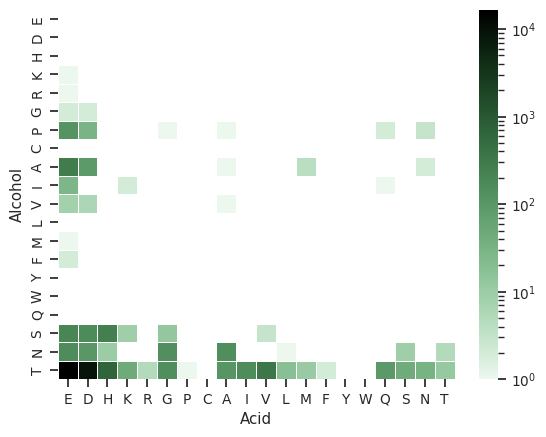

In [67]:
cmap = sns.cubehelix_palette(start=2, rot=0, dark=0, light=.95, as_cmap=True)
sns.set_style(style='ticks')
sns.axes_style({'font.sans-serif': 'Verdana'})

heatmap = sns.heatmap(
    heatmap_orderedAA,
    norm=LogNorm(),
    linecolor='white',
    linewidths=0.5,
    cmap=cmap
    )

heatmap.set(xlabel="Acid", ylabel="Alcohol")

